In [4]:
%pip install numpy pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Data handling
import numpy as np
import pandas as pd

# Visualization and exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Regression models and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR


from sklearn.impute import KNNImputer

# Regression evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Notebook display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv("crop_yield_dataset.csv")
print("Data loaded successfully. Here's a preview:")
df.head()
print("\nData summary:")
df.describe()

Data loaded successfully. Here's a preview:

Data summary:


,Rainfall_mm,Temperature_C,Soil_pH,Fertilizer_kg_per_ha,Pesticide_kg_per_ha,Sunlight_Hours_per_day,Farm_Size_ha,Crop_Yield_tonnes_per_ha
count,9995.000,10083.000,10091.000,9882.000,10013.000,10222.000,9996.000,10515.000
mean,910.446,24.036,6.504,149.494,5.017,7.480,5.372,8.135
std,255.016,5.037,0.810,60.756,2.452,1.518,17.083,1.451
min,100.000,5.000,3.680,0.000,0.000,2.200,0.200,4.270
25%,740.650,20.600,5.960,109.600,3.320,6.500,1.790,7.110
50%,908.800,24.000,6.500,148.900,4.960,7.500,3.280,7.960
75%,1076.500,27.400,7.050,189.275,6.690,8.500,6.062,9.040
max,3922.262,44.400,9.400,713.711,15.070,12.000,774.900,13.130


In [7]:
print("Displaying data types and non-null counts:")
df.info()

Displaying data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 10515 entries, 0 to 10514
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Soil_Type                 10184 non-null  str    
 1   Crop_Type                 10275 non-null  str    
 2   Rainfall_mm               9995 non-null   float64
 3   Temperature_C             10083 non-null  float64
 4   Soil_pH                   10091 non-null  float64
 5   Fertilizer_kg_per_ha      9882 non-null   float64
 6   Pesticide_kg_per_ha       10013 non-null  float64
 7   Sunlight_Hours_per_day    10222 non-null  float64
 8   Farm_Size_ha              9996 non-null   float64
 9   Irrigation                10204 non-null  str    
 10  Crop_Yield_tonnes_per_ha  10515 non-null  float64
dtypes: float64(8), str(3)
memory usage: 903.8 KB


In [8]:
print("\nChecking for missing values:")
print(df.isnull().sum())


Checking for missing values:
Soil_Type                   331
Crop_Type                   240
Rainfall_mm                 520
Temperature_C               432
Soil_pH                     424
Fertilizer_kg_per_ha        633
Pesticide_kg_per_ha         502
Sunlight_Hours_per_day      293
Farm_Size_ha                519
Irrigation                  311
Crop_Yield_tonnes_per_ha      0
dtype: int64


In [9]:
print("Checking for duplicate rows:")
print(df.duplicated().sum())

Checking for duplicate rows:
15


In [10]:
print("\n Checking for categorical variables:")
for col in df.columns:
    if df[col].dtype == 'str':
        print(f"{col}: {df[col].nunique()} unique values")



 Checking for categorical variables:
Soil_Type: 5 unique values
Crop_Type: 6 unique values
Irrigation: 2 unique values


In [11]:
print("\nUnique values in categorical columns:")
for col in df.columns:
    # Pandas usually stores strings as 'object' or 'string' type
    if df[col].dtype == "object" or df[col].dtype == "string":
        print()
        print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()}")



Unique values in categorical columns:

Soil_Type: 5 unique values -> <StringArray>
['Peaty', 'Clay', 'Silty', 'Sandy', 'Loamy', nan]
Length: 6, dtype: str

Crop_Type: 6 unique values -> <StringArray>
['Soybean', 'Wheat', 'Rice', 'Cotton', 'Barley', 'Maize', nan]
Length: 7, dtype: str

Irrigation: 2 unique values -> <StringArray>
['Yes', 'No', nan]
Length: 3, dtype: str


In [12]:
print("\nChecking for numerical variables:")
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        print(f"{col}: {df[col].describe()}")
        print()


Checking for numerical variables:
Rainfall_mm: count   9995.000
mean     910.446
std      255.016
min      100.000
25%      740.650
50%      908.800
75%     1076.500
max     3922.262
Name: Rainfall_mm, dtype: float64

Temperature_C: count   10083.000
mean       24.036
std         5.037
min         5.000
25%        20.600
50%        24.000
75%        27.400
max        44.400
Name: Temperature_C, dtype: float64

Soil_pH: count   10091.000
mean        6.504
std         0.810
min         3.680
25%         5.960
50%         6.500
75%         7.050
max         9.400
Name: Soil_pH, dtype: float64

Fertilizer_kg_per_ha: count   9882.000
mean     149.494
std       60.756
min        0.000
25%      109.600
50%      148.900
75%      189.275
max      713.711
Name: Fertilizer_kg_per_ha, dtype: float64

Pesticide_kg_per_ha: count   10013.000
mean        5.017
std         2.452
min         0.000
25%         3.320
50%         4.960
75%         6.690
max        15.070
Name: Pesticide_kg_per_ha, dtype: 

In [13]:
print("\n Checking for outliers using IQR method:")
no_of_outliers = 0
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
        print(f"{col}: {len(outliers)} outliers")
        #print(f"{col} outliers: {outliers}")
        print()
        print()
        no_of_outliers += len(outliers)


 Checking for outliers using IQR method:
Rainfall_mm: 65 outliers


Temperature_C: 75 outliers


Soil_pH: 75 outliers


Fertilizer_kg_per_ha: 34 outliers


Pesticide_kg_per_ha: 43 outliers


Sunlight_Hours_per_day: 74 outliers


Farm_Size_ha: 735 outliers


Crop_Yield_tonnes_per_ha: 49 outliers




Box plots for numerical variables:


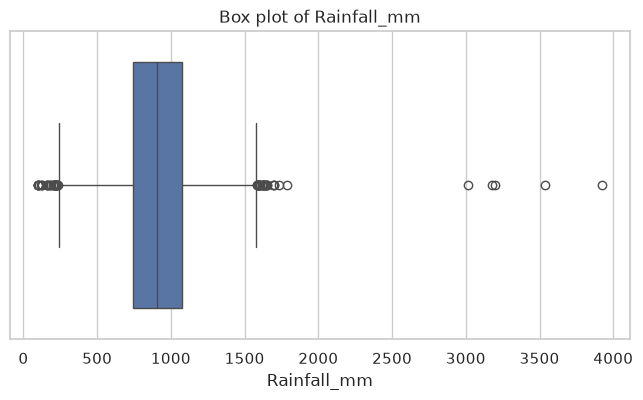

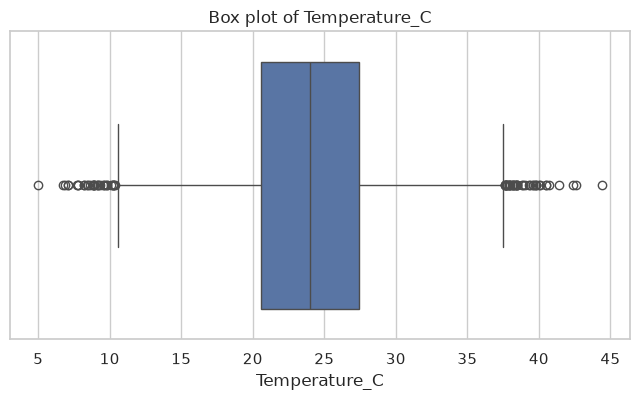

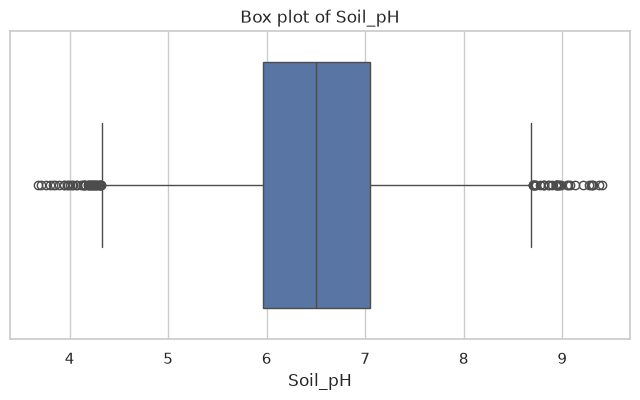

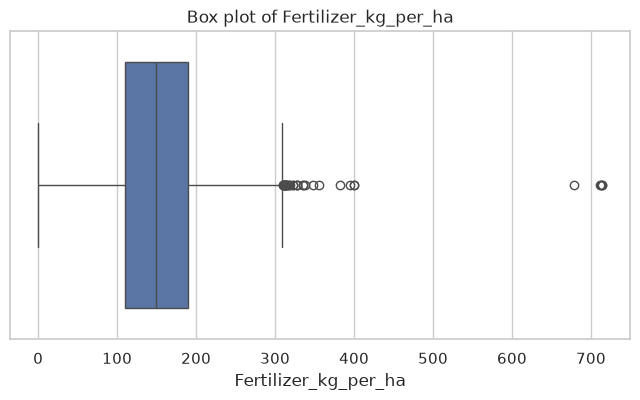

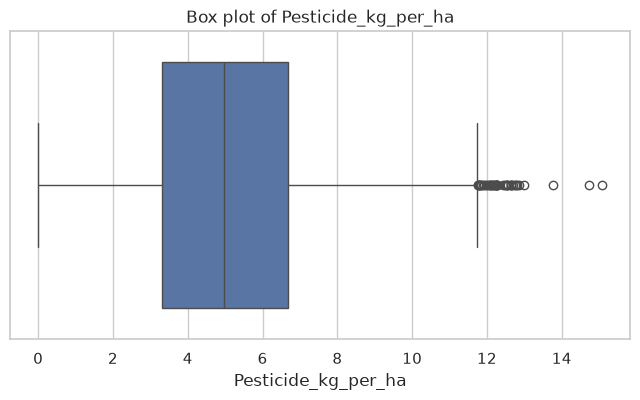

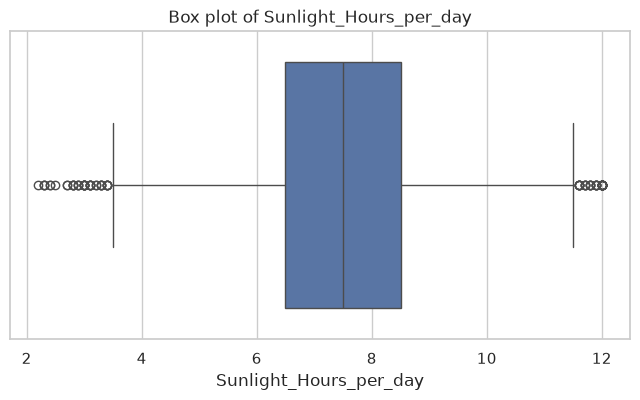

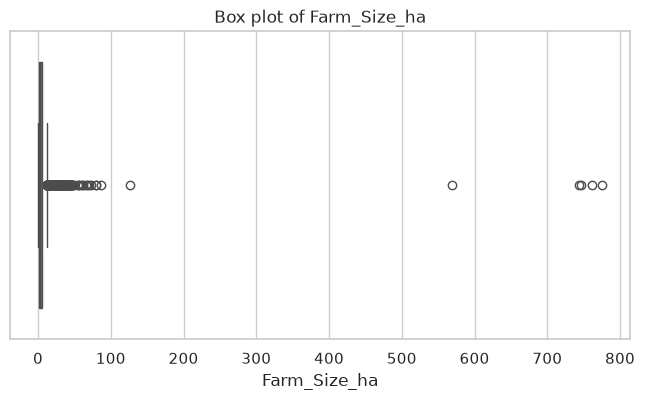

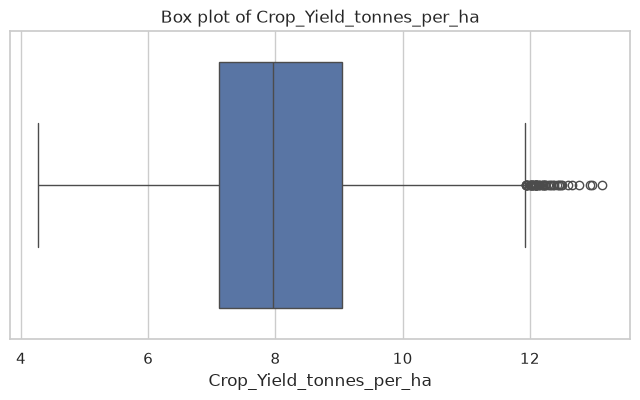

In [14]:
print("Box plots for numerical variables:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')

In [15]:
print("Data summary :")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Categorical columns: {len(df.select_dtypes(include=['object', 'string']).columns)}")
print(f"Numerical columns: {len(df.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Total outliers detected: {no_of_outliers}")
print(f"Total unique values in categorical columns: {sum(df[col].nunique() for col in df.select_dtypes(include=['object', 'string']).columns)}")
print(f"Total unique values in numerical columns: {sum(df[col].nunique() for col in df.select_dtypes(include=['int64', 'float64']).columns)}")

Data summary :
Rows: 10515, Columns: 11
Missing values: 4205
Duplicate rows: 15
Categorical columns: 3
Numerical columns: 8
Total outliers detected: 1150
Total unique values in categorical columns: 13
Total unique values in numerical columns: 13231


In [16]:
print("Capping all the outliers in the dataset with the 1st and 99th percentiles:")
for col in numerical_cols:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    print(f"Column {col}: Lower bound = {lower_bound}, Upper bound = {upper_bound}")

print("Capping of outliers completed successfully.")
print("Data after capping outliers:")
print(df.head())


Capping all the outliers in the dataset with the 1st and 99th percentiles:
Column Rainfall_mm: Lower bound = 330.164, Upper bound = 1488.4299999999998
Column Temperature_C: Lower bound = 12.4, Upper bound = 35.9
Column Soil_pH: Lower bound = 4.59, Upper bound = 8.42
Column Fertilizer_kg_per_ha: Lower bound = 7.624000000000001, Upper bound = 286.7380000000001
Column Pesticide_kg_per_ha: Lower bound = 0.0, Upper bound = 10.857599999999984
Column Sunlight_Hours_per_day: Lower bound = 4.0, Upper bound = 11.0
Column Farm_Size_ha: Lower bound = 0.42, Upper bound = 28.908999999999867
Column Crop_Yield_tonnes_per_ha: Lower bound = 5.2514, Upper bound = 11.578600000000005
Capping of outliers completed successfully.
Data after capping outliers:
  Soil_Type Crop_Type  Rainfall_mm  Temperature_C  Soil_pH  \
0     Peaty   Soybean      633.700         22.700    6.000   
1     Peaty     Wheat          NaN         23.900    6.050   
2     Peaty      Rice      423.600         17.400    5.770   
3      

In [17]:
print("Using KNN Imputer to fill missing values in the dataset:")
knn_imputer = KNNImputer(n_neighbors=5)
df[numerical_cols] = knn_imputer.fit_transform(df[numerical_cols])
print("KNN Imputation completed successfully.")


Using KNN Imputer to fill missing values in the dataset:
KNN Imputation completed successfully.


In [18]:
print("Missing values after KNN Imputation: ", df.isnull().sum())


Missing values after KNN Imputation:  Soil_Type                   331
Crop_Type                   240
Rainfall_mm                   0
Temperature_C                 0
Soil_pH                       0
Fertilizer_kg_per_ha          0
Pesticide_kg_per_ha           0
Sunlight_Hours_per_day        0
Farm_Size_ha                  0
Irrigation                  311
Crop_Yield_tonnes_per_ha      0
dtype: int64


In [19]:
df['Crop_Type']

0        Soybean
1          Wheat
2           Rice
3           Rice
4          Wheat
          ...   
10510       Rice
10511    Soybean
10512     Barley
10513      Wheat
10514    Soybean
Name: Crop_Type, Length: 10515, dtype: str

In [20]:
print("Deleting all the missing categorical values")
df = df.dropna(subset=["Irrigation","Crop_Type"])
print("Missing values after deleting missing categorical values: ", df.isnull().sum())

Deleting all the missing categorical values
Missing values after deleting missing categorical values:  Soil_Type                   308
Crop_Type                     0
Rainfall_mm                   0
Temperature_C                 0
Soil_pH                       0
Fertilizer_kg_per_ha          0
Pesticide_kg_per_ha           0
Sunlight_Hours_per_day        0
Farm_Size_ha                  0
Irrigation                    0
Crop_Yield_tonnes_per_ha      0
dtype: int64


In [21]:
df.head()


,Soil_Type,Crop_Type,Rainfall_mm,Temperature_C,Soil_pH,Fertilizer_kg_per_ha,Pesticide_kg_per_ha,Sunlight_Hours_per_day,Farm_Size_ha,Irrigation,Crop_Yield_tonnes_per_ha
0,Peaty,Soybean,633.700,22.700,6.000,137.200,4.150,7.400,3.360,Yes,8.160
1,Peaty,Wheat,1068.540,23.900,6.050,50.800,4.180,11.000,7.108,No,6.560
2,Peaty,Rice,423.600,17.400,5.770,247.400,7.450,9.000,1.320,No,8.340
3,Clay,Rice,965.200,27.200,5.850,97.400,4.050,8.200,4.300,No,7.840
4,Peaty,Wheat,1056.700,27.300,5.550,252.000,7.760,6.900,1.340,Yes,8.220


In [22]:
duplicate_rows = df[df.duplicated()]
if not duplicate_rows.empty:
    print(f"{len(duplicate_rows)} Duplicate rows found")
    #print(duplicate_rows)
    # Optionally, you can drop the duplicate rows
    df = df.drop_duplicates()
print("Duplicate rows after dropping duplicates: ", df.duplicated().sum())


14 Duplicate rows found
Duplicate rows after dropping duplicates:  0


In [23]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

In [24]:
#One hot encoding for categorical variables
df = pd.get_dummies(df, columns=categorical_cols, dtype=int,drop_first=True)
print("Data after one-hot encoding:")
print(df.head())



Data after one-hot encoding:
   Rainfall_mm  Temperature_C  Soil_pH  Fertilizer_kg_per_ha  \
0      633.700         22.700    6.000               137.200   
1     1068.540         23.900    6.050                50.800   
2      423.600         17.400    5.770               247.400   
3      965.200         27.200    5.850                97.400   
4     1056.700         27.300    5.550               252.000   

   Pesticide_kg_per_ha  Sunlight_Hours_per_day  Farm_Size_ha  \
0                4.150                   7.400         3.360   
1                4.180                  11.000         7.108   
2                7.450                   9.000         1.320   
3                4.050                   8.200         4.300   
4                7.760                   6.900         1.340   

   Crop_Yield_tonnes_per_ha  Soil_Type_Loamy  Soil_Type_Peaty  \
0                     8.160                0                1   
1                     6.560                0                1   
2     

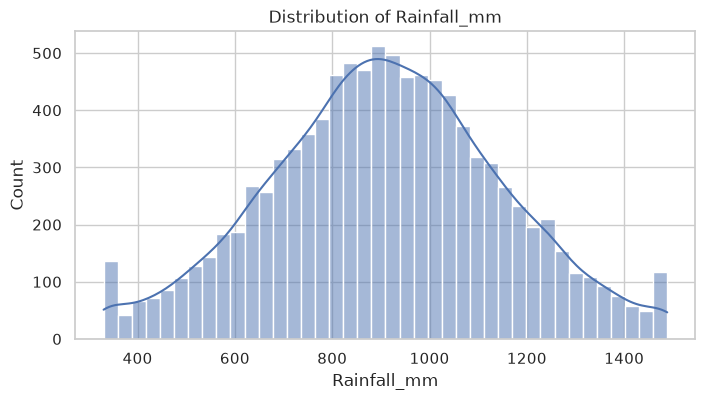

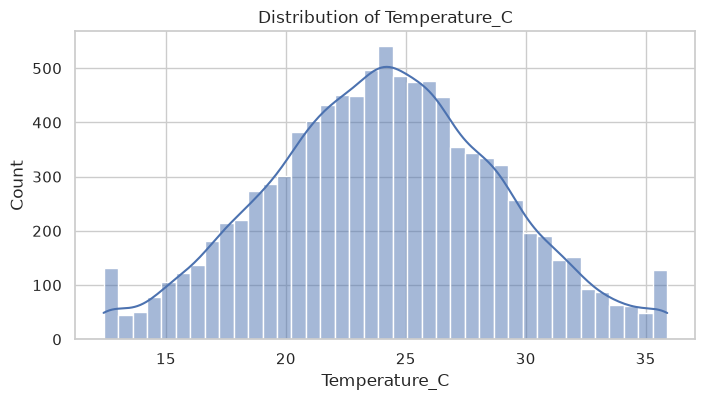

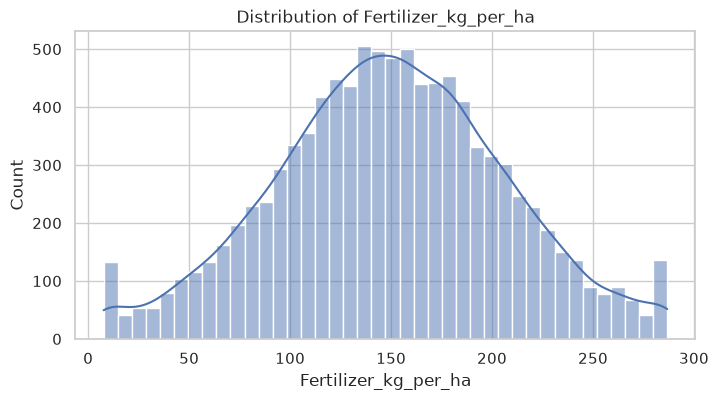

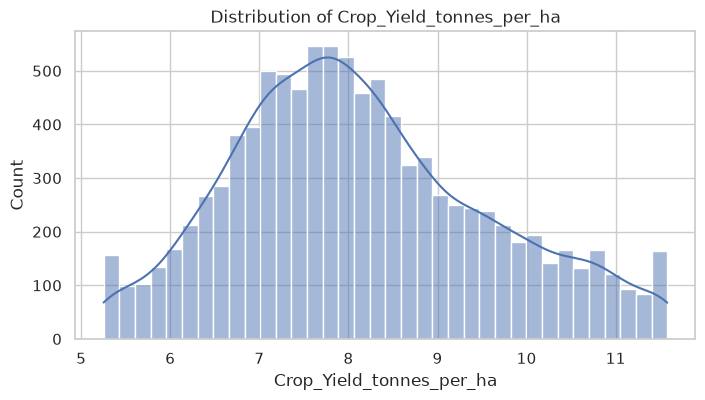

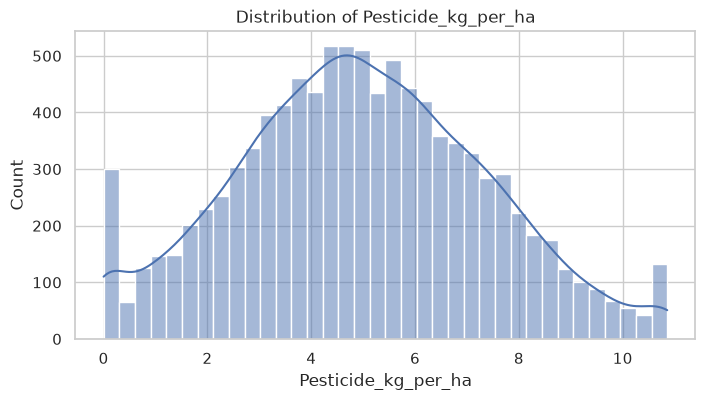

In [25]:
#Univariate Analysis- Distributions
numeric_dist_cols = ['Rainfall_mm', 'Temperature_C', 'Fertilizer_kg_per_ha', 'Crop_Yield_tonnes_per_ha','Pesticide_kg_per_ha']

for col in numeric_dist_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()

In [26]:
#Categorical Analysis-Soil_Type, Crop_Type, and Irrigation
soil_cols = []
for col in df.columns:
    if col.startswith('Soil_Type_'):
        soil_cols.append(col)

crop_cols = []
for col in df.columns:
    if col.startswith('Crop_Type_'):
        crop_cols.append(col)

irrigation_cols = []
for col in df.columns:
    if col.startswith('Irrigation_'):
        irrigation_cols.append(col)

print("Soil Type counts:")
print(df[soil_cols].sum())

print("\nCrop Type counts:")
print(df[crop_cols].sum())

print("\nIrrigation counts:")
print(df[irrigation_cols].sum())

Soil Type counts:
Soil_Type_Loamy    1887
Soil_Type_Peaty    1865
Soil_Type_Sandy    1962
Soil_Type_Silty    1972
dtype: int64

Crop Type counts:
Crop_Type_Cotton     1709
Crop_Type_Maize      1602
Crop_Type_Rice       1707
Crop_Type_Soybean    1683
Crop_Type_Wheat      1598
dtype: int64

Irrigation counts:
Irrigation_Yes    5488
dtype: int64


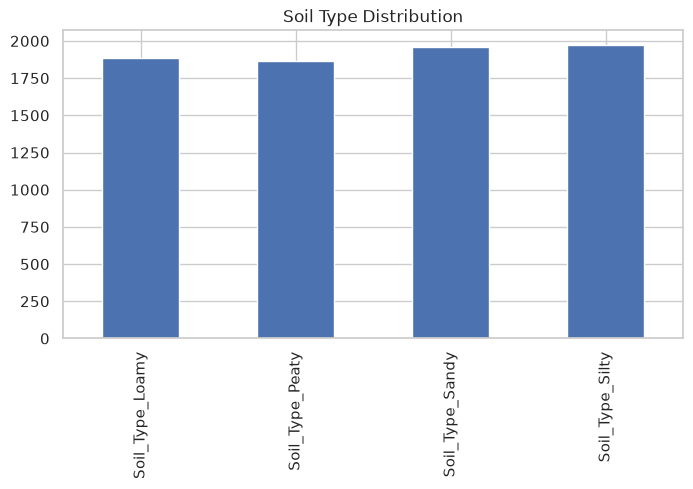

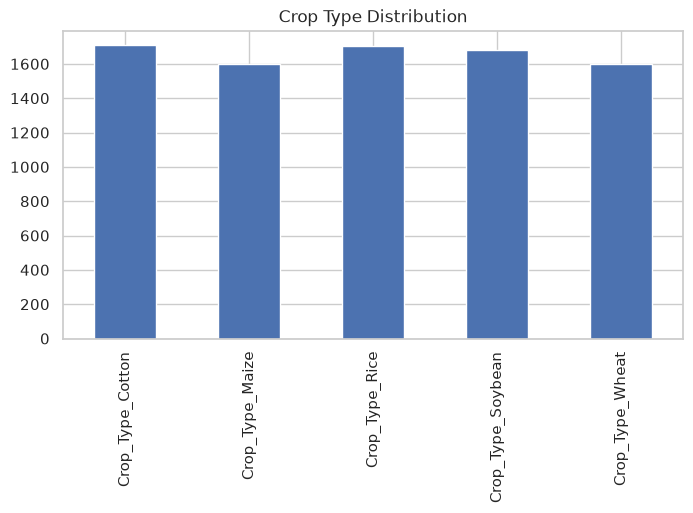

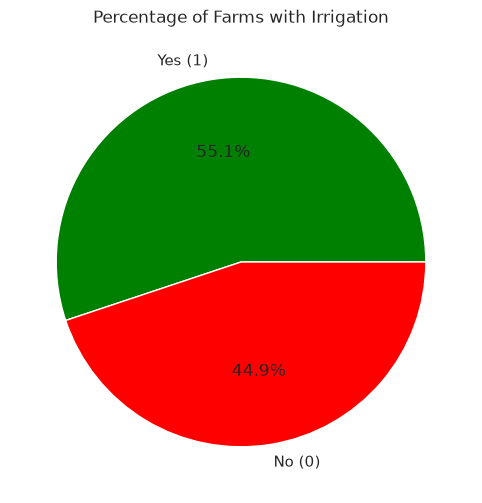

In [27]:
plt.figure(figsize=(8, 4))
df[soil_cols].sum().plot(kind='bar')
plt.title('Soil Type Distribution')
plt.show()

plt.figure(figsize=(8, 4))
df[crop_cols].sum().plot(kind='bar')
plt.title('Crop Type Distribution')
plt.show()

plt.figure(figsize=(6, 6))
df['Irrigation_Yes'].value_counts().plot(
    kind='pie',  
    autopct='%1.1f%%',
    labels=['Yes (1)', 'No (0)'], 
    colors=['green', 'red']
)
plt.title('Percentage of Farms with Irrigation')
plt.ylabel('') 
plt.show()

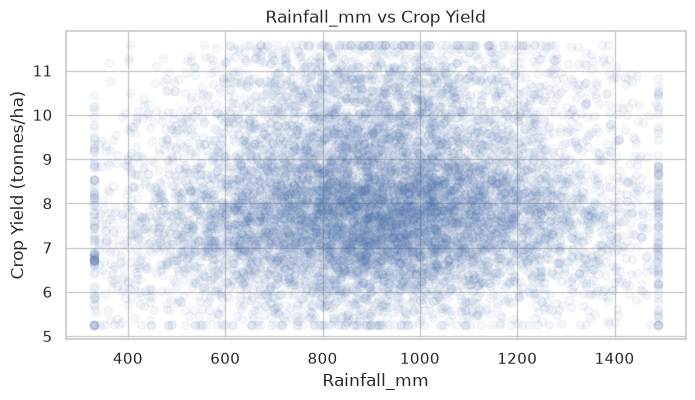

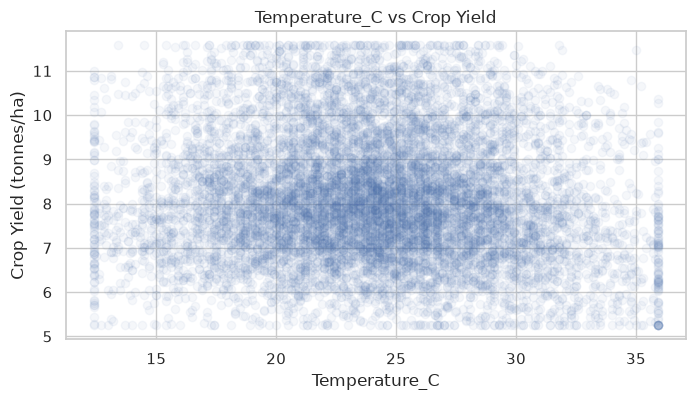

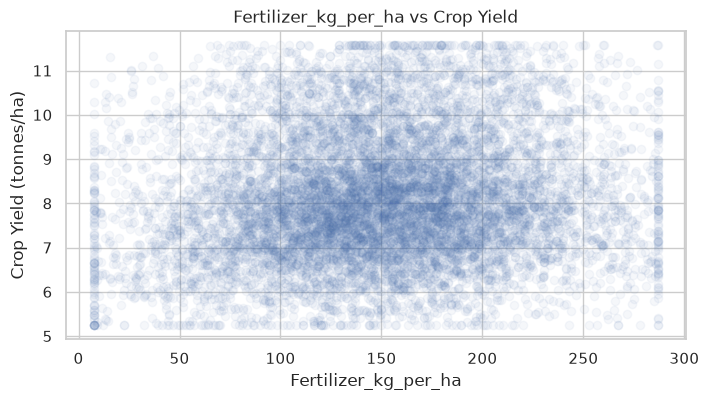

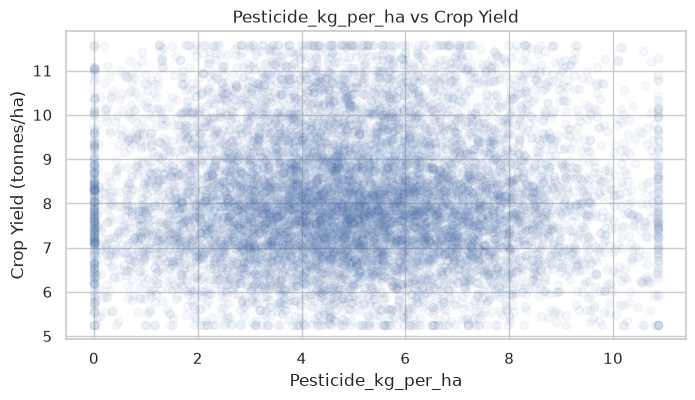

In [28]:
#Relationship Analysis
numeric_vs_yield = ['Rainfall_mm', 'Temperature_C', 'Fertilizer_kg_per_ha','Pesticide_kg_per_ha']

for col in numeric_vs_yield:
    plt.figure(figsize=(8, 4))
    plt.scatter(df[col], df['Crop_Yield_tonnes_per_ha'], alpha=0.05)
    plt.xlabel(col)
    plt.ylabel('Crop Yield (tonnes/ha)')
    plt.title(f'{col} vs Crop Yield')
    plt.show()

Average Crop Yield for each Soil Type:
Soil_Type_Loamy -> 8.72
Soil_Type_Peaty -> 8.09
Soil_Type_Sandy -> 7.66
Soil_Type_Silty -> 8.24


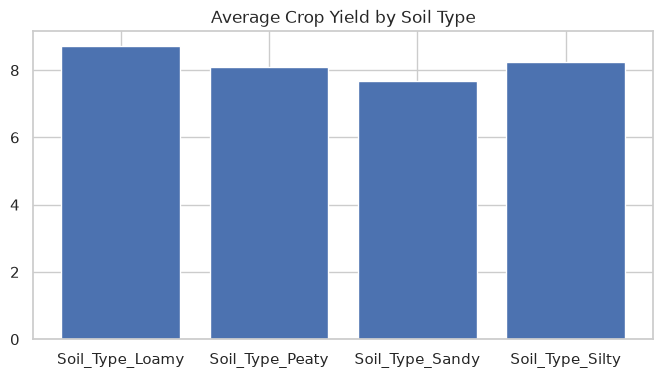

In [29]:
print("Average Crop Yield for each Soil Type:")
for col in soil_cols:
    avg_yield = df[df[col] == 1]['Crop_Yield_tonnes_per_ha'].mean()
    print(col, "->", round(avg_yield, 2))

avg_list = []
for col in soil_cols:
    avg_list.append(df[df[col] == 1]['Crop_Yield_tonnes_per_ha'].mean())

plt.figure(figsize=(8, 4))
plt.bar(soil_cols, avg_list)
plt.title('Average Crop Yield by Soil Type')
plt.show()

Average Crop Yield for each Crop Type:
Crop_Type_Cotton -> 6.69
Crop_Type_Maize -> 10.37
Crop_Type_Rice -> 8.87
Crop_Type_Soybean -> 7.39
Crop_Type_Wheat -> 7.88


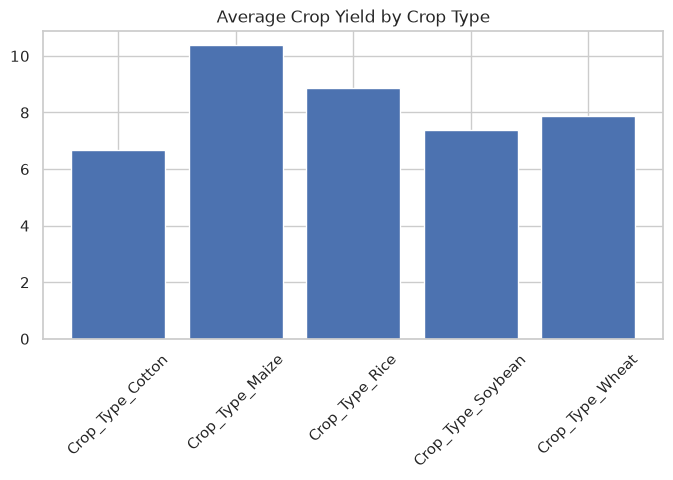

In [30]:
print("Average Crop Yield for each Crop Type:")
for col in crop_cols:
    avg_yield = df[df[col] == 1]['Crop_Yield_tonnes_per_ha'].mean()
    print(col, "->", round(avg_yield, 2))

avg_list = []
for col in crop_cols:
    avg_list.append(df[df[col] == 1]['Crop_Yield_tonnes_per_ha'].mean())

plt.figure(figsize=(8, 4))
plt.bar(crop_cols, avg_list)
plt.title('Average Crop Yield by Crop Type')
plt.xticks(rotation=45)
plt.show()

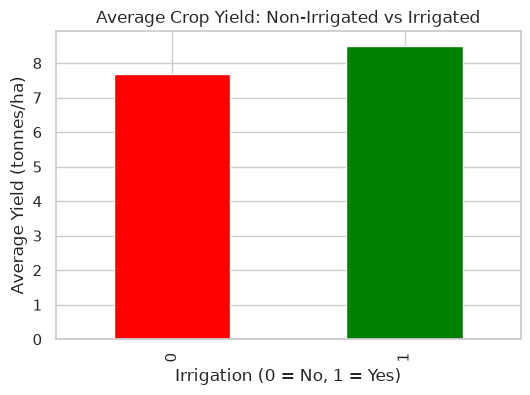

In [31]:
#Average Crop Yield: Irrigated vs Non-Irrigated
plt.figure(figsize=(6, 4))
df.groupby('Irrigation_Yes')['Crop_Yield_tonnes_per_ha'].mean().plot(kind='bar', color=['red', 'green'])
plt.title('Average Crop Yield: Non-Irrigated vs Irrigated')
plt.xlabel('Irrigation (0 = No, 1 = Yes)')
plt.ylabel('Average Yield (tonnes/ha)')
plt.show()

                          Rainfall_mm  Temperature_C  Soil_pH  \
Rainfall_mm                     1.000         -0.006    0.008   
Temperature_C                  -0.006          1.000   -0.012   
Soil_pH                         0.008         -0.012    1.000   
Fertilizer_kg_per_ha            0.004          0.013   -0.004   
Pesticide_kg_per_ha            -0.002         -0.004   -0.006   
Sunlight_Hours_per_day         -0.007          0.003   -0.014   
Farm_Size_ha                   -0.015          0.007   -0.016   
Crop_Yield_tonnes_per_ha        0.047         -0.093    0.000   

                          Fertilizer_kg_per_ha  Pesticide_kg_per_ha  \
Rainfall_mm                              0.004               -0.002   
Temperature_C                            0.013               -0.004   
Soil_pH                                 -0.004               -0.006   
Fertilizer_kg_per_ha                     1.000                0.005   
Pesticide_kg_per_ha                      0.005             

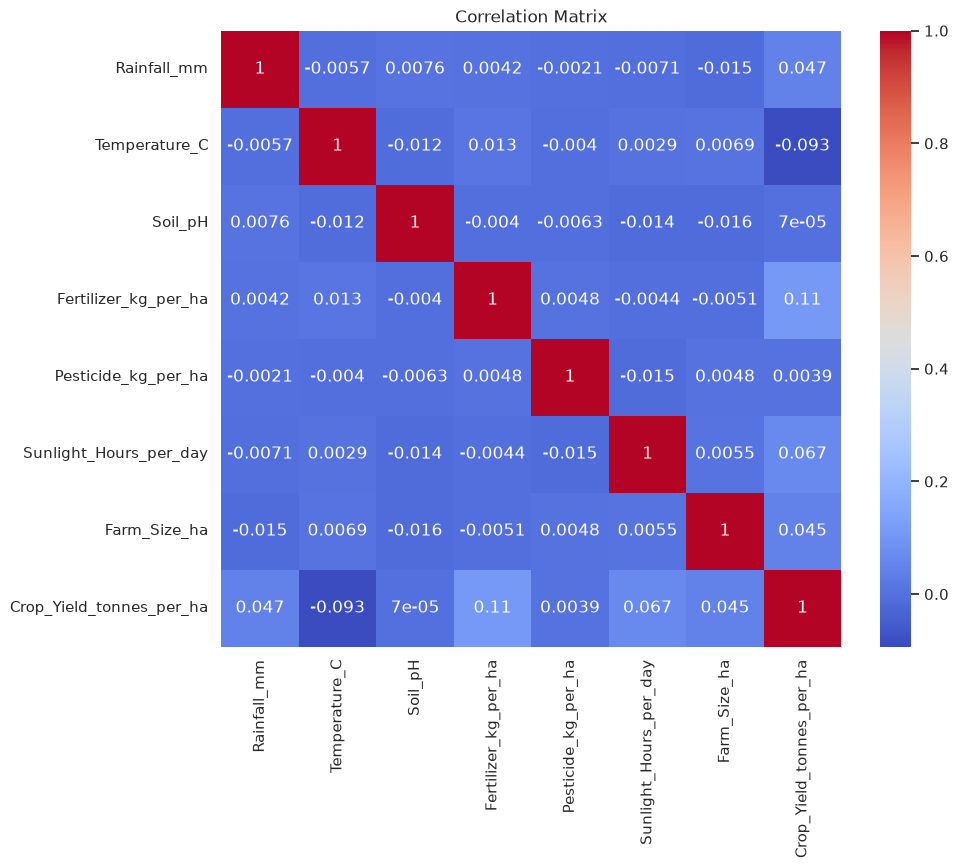


Correlation with Crop Yield (sorted):
Crop_Yield_tonnes_per_ha    1.000
Fertilizer_kg_per_ha        0.109
Sunlight_Hours_per_day      0.067
Rainfall_mm                 0.047
Farm_Size_ha                0.045
Pesticide_kg_per_ha         0.004
Soil_pH                     0.000
Temperature_C              -0.093
Name: Crop_Yield_tonnes_per_ha, dtype: float64


In [32]:
# Correlation & Insights
numeric_cols_all = ['Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Fertilizer_kg_per_ha',
                    'Pesticide_kg_per_ha', 'Sunlight_Hours_per_day', 'Farm_Size_ha',
                    'Crop_Yield_tonnes_per_ha']

corr_matrix = df[numeric_cols_all].corr()
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

print("\nCorrelation with Crop Yield (sorted):")
print(corr_matrix['Crop_Yield_tonnes_per_ha'].sort_values(ascending=False))

In [33]:
cols_list = ['Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Fertilizer_kg_per_ha',
             'Pesticide_kg_per_ha', 'Sunlight_Hours_per_day', 'Farm_Size_ha']

print("Checking for highly correlated numeric features (above 0.5):")
found_correlation = False
for i in range(len(cols_list)):
    for j in range(i + 1, len(cols_list)):
        value = corr_matrix.loc[cols_list[i], cols_list[j]]
        if abs(value) > 0.5:
            print(cols_list[i], "and", cols_list[j], "are highly correlated:", value)
            found_correlation = True
if not found_correlation:
    print("None of the numeric features are highly correlated with each other.")

Checking for highly correlated numeric features (above 0.5):
None of the numeric features are highly correlated with each other.


##Key EDA Findings
* Correlations between individual weather/input features and yield are weak -- Fertilizer, Sunlight Hours, and Rainfall show the  strongest (still weak) positive relationships; Temperature is weakly negative.
* No numeric feature pairs show correlation above 0.5, so there's no strong redundancy among the numeric features.
* Crop type is a major yield driver -- Maize clearly outperforms Cotton and Soybean on average yield.
* Soil type matters -- Loamy and Silty soils outperform Sandy soil.
* Irrigation gives a clear yield boost -- irrigated farms outyield non-irrigated ones.
* Weather variables alone are poor single predictors of yield, suggesting yield is driven more by crop choice, soil, and irrigation than by rainfall/temperature alone.
* Categories are fairly balanced overall, so no severe class-imbalance concerns.

In [34]:

numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
['Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Fertilizer_kg_per_ha', 'Pesticide_kg_per_ha', 'Sunlight_Hours_per_day', 'Farm_Size_ha', 'Crop_Yield_tonnes_per_ha', 'Soil_Type_Loamy', 'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silty', 'Crop_Type_Cotton', 'Crop_Type_Maize', 'Crop_Type_Rice', 'Crop_Type_Soybean', 'Crop_Type_Wheat', 'Irrigation_Yes']

Categorical Features:
[]


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[numerical_features] = scaler.fit_transform(
    df[numerical_features]
)

In [36]:
print("Preparing features and target:")

X = df_scaled.drop("Crop_Yield_tonnes_per_ha", axis=1)
y = df_scaled["Crop_Yield_tonnes_per_ha"]

print("Features:", X.columns.tolist())
print("Target: Crop_Yield_tonnes_per_ha")

Preparing features and target:
Features: ['Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Fertilizer_kg_per_ha', 'Pesticide_kg_per_ha', 'Sunlight_Hours_per_day', 'Farm_Size_ha', 'Soil_Type_Loamy', 'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silty', 'Crop_Type_Cotton', 'Crop_Type_Maize', 'Crop_Type_Rice', 'Crop_Type_Soybean', 'Crop_Type_Wheat', 'Irrigation_Yes']
Target: Crop_Yield_tonnes_per_ha


In [37]:
print(df.columns.tolist())

['Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Fertilizer_kg_per_ha', 'Pesticide_kg_per_ha', 'Sunlight_Hours_per_day', 'Farm_Size_ha', 'Crop_Yield_tonnes_per_ha', 'Soil_Type_Loamy', 'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silty', 'Crop_Type_Cotton', 'Crop_Type_Maize', 'Crop_Type_Rice', 'Crop_Type_Soybean', 'Crop_Type_Wheat', 'Irrigation_Yes']


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 7964
Testing rows: 1992


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Multiple Linear Regression completed")

Multiple Linear Regression completed


In [41]:
poly_model = make_pipeline(
    PolynomialFeatures(2),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

print("Polynomial Regression completed")

Polynomial Regression completed


In [42]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

print("Ridge Regression completed")

Ridge Regression completed


In [43]:
lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

print("Lasso Regression completed")

Lasso Regression completed


In [44]:
elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(X_train, y_train)

y_pred_elastic = elastic_model.predict(X_test)

print("ElasticNet Regression completed")

ElasticNet Regression completed


In [45]:
print("\nMultiple Linear Regression:")

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


Multiple Linear Regression:
MAE: 0.33136221442014635
MSE: 0.17625943705809569
RMSE: 0.41983262981585373
R2 Score: 0.8281838432501188


evaluate plynomial regression

In [46]:
print("\nPolynomial Regression:")

print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
print("R2 Score:", r2_score(y_test, y_pred_poly))


Polynomial Regression:
MAE: 0.26968489726081274
MSE: 0.11483191517080382
RMSE: 0.3388685809732201
R2 Score: 0.8880628540168728


evaluate ridge regression


In [47]:
print("\nRidge Regression:")

print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))


Ridge Regression:
MAE: 0.3313658893184536
MSE: 0.1762607357256882
RMSE: 0.41983417646219345
R2 Score: 0.8281825773203146


In [48]:
print("\nLasso Regression:")

print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2 Score:", r2_score(y_test, y_pred_lasso))


Lasso Regression:
MAE: 0.33567555699286816
MSE: 0.1792470631836337
RMSE: 0.4233757942816685
R2 Score: 0.8252715314484745


In [49]:
print("\nElasticNet Regression:")

print("MAE:", mean_absolute_error(y_test, y_pred_elastic))
print("MSE:", mean_squared_error(y_test, y_pred_elastic))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))
print("R2 Score:", r2_score(y_test, y_pred_elastic))


ElasticNet Regression:
MAE: 0.3333296774536723
MSE: 0.1774498502463561
RMSE: 0.42124796764655864
R2 Score: 0.8270234388918327


In [50]:
comparison_df = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression"
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_poly),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_elastic)
    ],

    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred_poly),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_elastic)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_elastic))
    ],

    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elastic)
    ]
})

display(comparison_df.round(4))

,Model,MAE,MSE,RMSE,R2 Score
0,Multiple Linear Regression,0.331,0.176,0.420,0.828
1,Polynomial Regression,0.270,0.115,0.339,0.888
2,Ridge Regression,0.331,0.176,0.420,0.828
3,Lasso Regression,0.336,0.179,0.423,0.825
4,ElasticNet Regression,0.333,0.177,0.421,0.827


Get predictions for training data

In [51]:
print("Generating training predictions:")

y_train_pred = model.predict(X_train)
y_train_pred_poly = poly_model.predict(X_train)
y_train_pred_ridge = ridge_model.predict(X_train)
y_train_pred_lasso = lasso_model.predict(X_train)
y_train_pred_elastic = elastic_model.predict(X_train)

print("Training predictions completed.")

Generating training predictions:
Training predictions completed.


compare testing and training r2

In [52]:
print("\nTraining and Testing R2 Scores:")

train_test_r2 = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression"
    ],
    "Training R2": [
        r2_score(y_train, y_train_pred),
        r2_score(y_train, y_train_pred_poly),
        r2_score(y_train, y_train_pred_ridge),
        r2_score(y_train, y_train_pred_lasso),
        r2_score(y_train, y_train_pred_elastic)
    ],
    "Testing R2": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elastic)
    ]
})

display(train_test_r2.round(4))


Training and Testing R2 Scores:


,Model,Training R2,Testing R2
0,Multiple Linear Regression,0.829,0.828
1,Polynomial Regression,0.890,0.888
2,Ridge Regression,0.829,0.828
3,Lasso Regression,0.828,0.825
4,ElasticNet Regression,0.829,0.827


compare testing and training RMSE

In [53]:
print("\nTraining and Testing RMSE:")

train_test_rmse = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression"
    ],
    "Training RMSE": [
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_poly)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_ridge)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_lasso)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_elastic))
    ],
    "Testing RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_elastic))
    ]
})

display(train_test_rmse.round(4))


Training and Testing RMSE:


,Model,Training RMSE,Testing RMSE
0,Multiple Linear Regression,0.412,0.420
1,Polynomial Regression,0.330,0.339
2,Ridge Regression,0.412,0.420
3,Lasso Regression,0.414,0.423
4,ElasticNet Regression,0.412,0.421


Check R² gap

In [54]:
print("\nChecking Training-Testing R2 Gap:")

train_test_r2["R2 Gap"] = (
    train_test_r2["Training R2"] -
    train_test_r2["Testing R2"]
)

display(train_test_r2.round(4))


Checking Training-Testing R2 Gap:


,Model,Training R2,Testing R2,R2 Gap
0,Multiple Linear Regression,0.829,0.828,0.001
1,Polynomial Regression,0.890,0.888,0.002
2,Ridge Regression,0.829,0.828,0.001
3,Lasso Regression,0.828,0.825,0.002
4,ElasticNet Regression,0.829,0.827,0.002


residual analysis

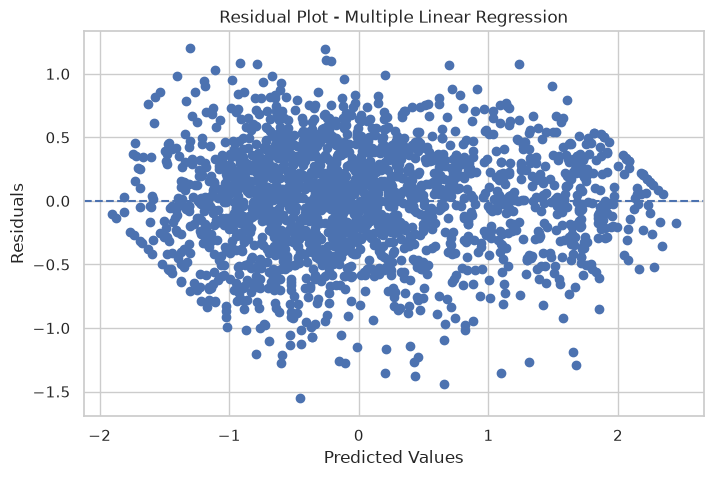

In [55]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Multiple Linear Regression")
plt.show()

Actual vs Predicted Values

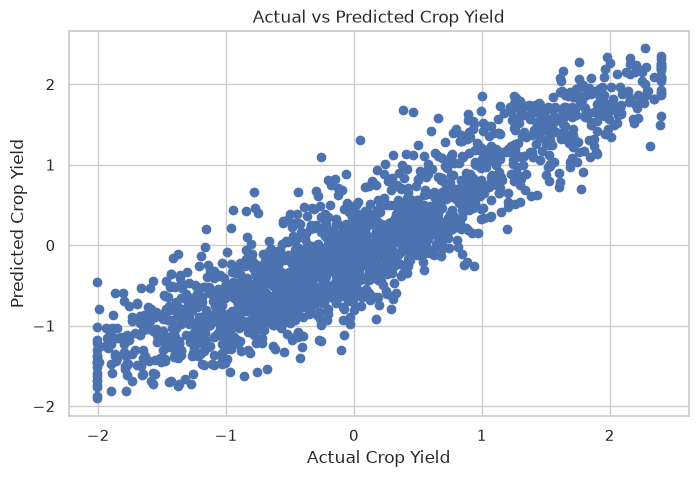

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Crop Yield")
plt.ylabel("Predicted Crop Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.show()

In [57]:
print("Feature Coefficients:")

feature_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

display(feature_coefficients)


Feature Coefficients:


,Feature,Coefficient
0,Rainfall_mm,0.037
1,Temperature_C,-0.088
2,Soil_pH,0.000
3,Fertilizer_kg_per_ha,0.109
4,Pesticide_kg_per_ha,0.006
5,Sunlight_Hours_per_day,0.067
6,Farm_Size_ha,0.034
7,Soil_Type_Loamy,0.198
8,Soil_Type_Peaty,0.021
9,Soil_Type_Sandy,-0.087


In [58]:
print("Features required for prediction:")

print(X.columns.tolist())

Features required for prediction:
['Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Fertilizer_kg_per_ha', 'Pesticide_kg_per_ha', 'Sunlight_Hours_per_day', 'Farm_Size_ha', 'Soil_Type_Loamy', 'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silty', 'Crop_Type_Cotton', 'Crop_Type_Maize', 'Crop_Type_Rice', 'Crop_Type_Soybean', 'Crop_Type_Wheat', 'Irrigation_Yes']


In [59]:
new_data = pd.DataFrame({
    "Rainfall_mm": [800],
    "Temperature_C": [25],
    "Soil_pH": [6.5],
    "Fertilizer_kg_per_ha": [100],
    "Pesticide_kg_per_ha": [20],
    "Sunlight_Hours_per_day": [7],
    "Farm_Size_ha": [5],
    "Soil_Type_Loamy": [1],
    "Soil_Type_Peaty": [0],
    "Soil_Type_Sandy": [0],
    "Soil_Type_Silty": [0],
    "Crop_Type_Cotton": [0],
    "Crop_Type_Maize": [1],
    "Crop_Type_Rice": [0],
    "Crop_Type_Soybean": [0],
    "Crop_Type_Wheat": [0],
    "Irrigation_Yes": [1]
})

prediction

In [60]:
predicted_yield = model.predict(new_data)

print("Predicted Crop Yield:", predicted_yield[0])

Predicted Crop Yield: 40.113779632349846


save the model

In [61]:
import joblib

joblib.dump(model, "crop_yield_model.pkl")

print("Model saved successfully as crop_yield_model.pkl")

Model saved successfully as crop_yield_model.pkl


load model

In [62]:
loaded_model = joblib.load("crop_yield_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


test the model

In [63]:
prediction = loaded_model.predict(new_data)

print("Predicted Crop Yield:", prediction[0])

Predicted Crop Yield: 40.113779632349846
